                                      Proiect 5 – Ensemble

1. Explorarea inițială a datelor

In [75]:
# Importarea bibliotecilor
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
# Citirea fișierul CSV
df = pd.read_csv('ensemble_1.csv')

In [77]:
# Verificarea primelor 5 rânduri pentru a confirma încărcarea corectă
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [78]:
# Eliminarea coloanelor irelevante

df = df.drop(['ID', 'ZIP Code'], axis=1)

In [79]:
# Afișarea primelor 5 observații

df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


In [80]:
df.shape

(5000, 12)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   Family              5000 non-null   int64  
 4   CCAvg               5000 non-null   float64
 5   Education           5000 non-null   int64  
 6   Mortgage            5000 non-null   int64  
 7   Personal Loan       5000 non-null   int64  
 8   Securities Account  5000 non-null   int64  
 9   CD Account          5000 non-null   int64  
 10  Online              5000 non-null   int64  
 11  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 468.9 KB


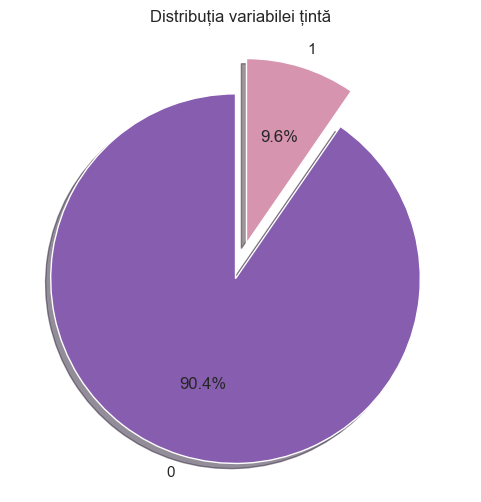

In [82]:
counts = df['Personal Loan'].value_counts()
labels = counts.index
sizes = counts.values

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    explode=[0.1, 0.1],  # corectat
    colors=[ '#875DAF', '#D794AF'],
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)
plt.title('Distribuția variabilei țintă')
plt.show()

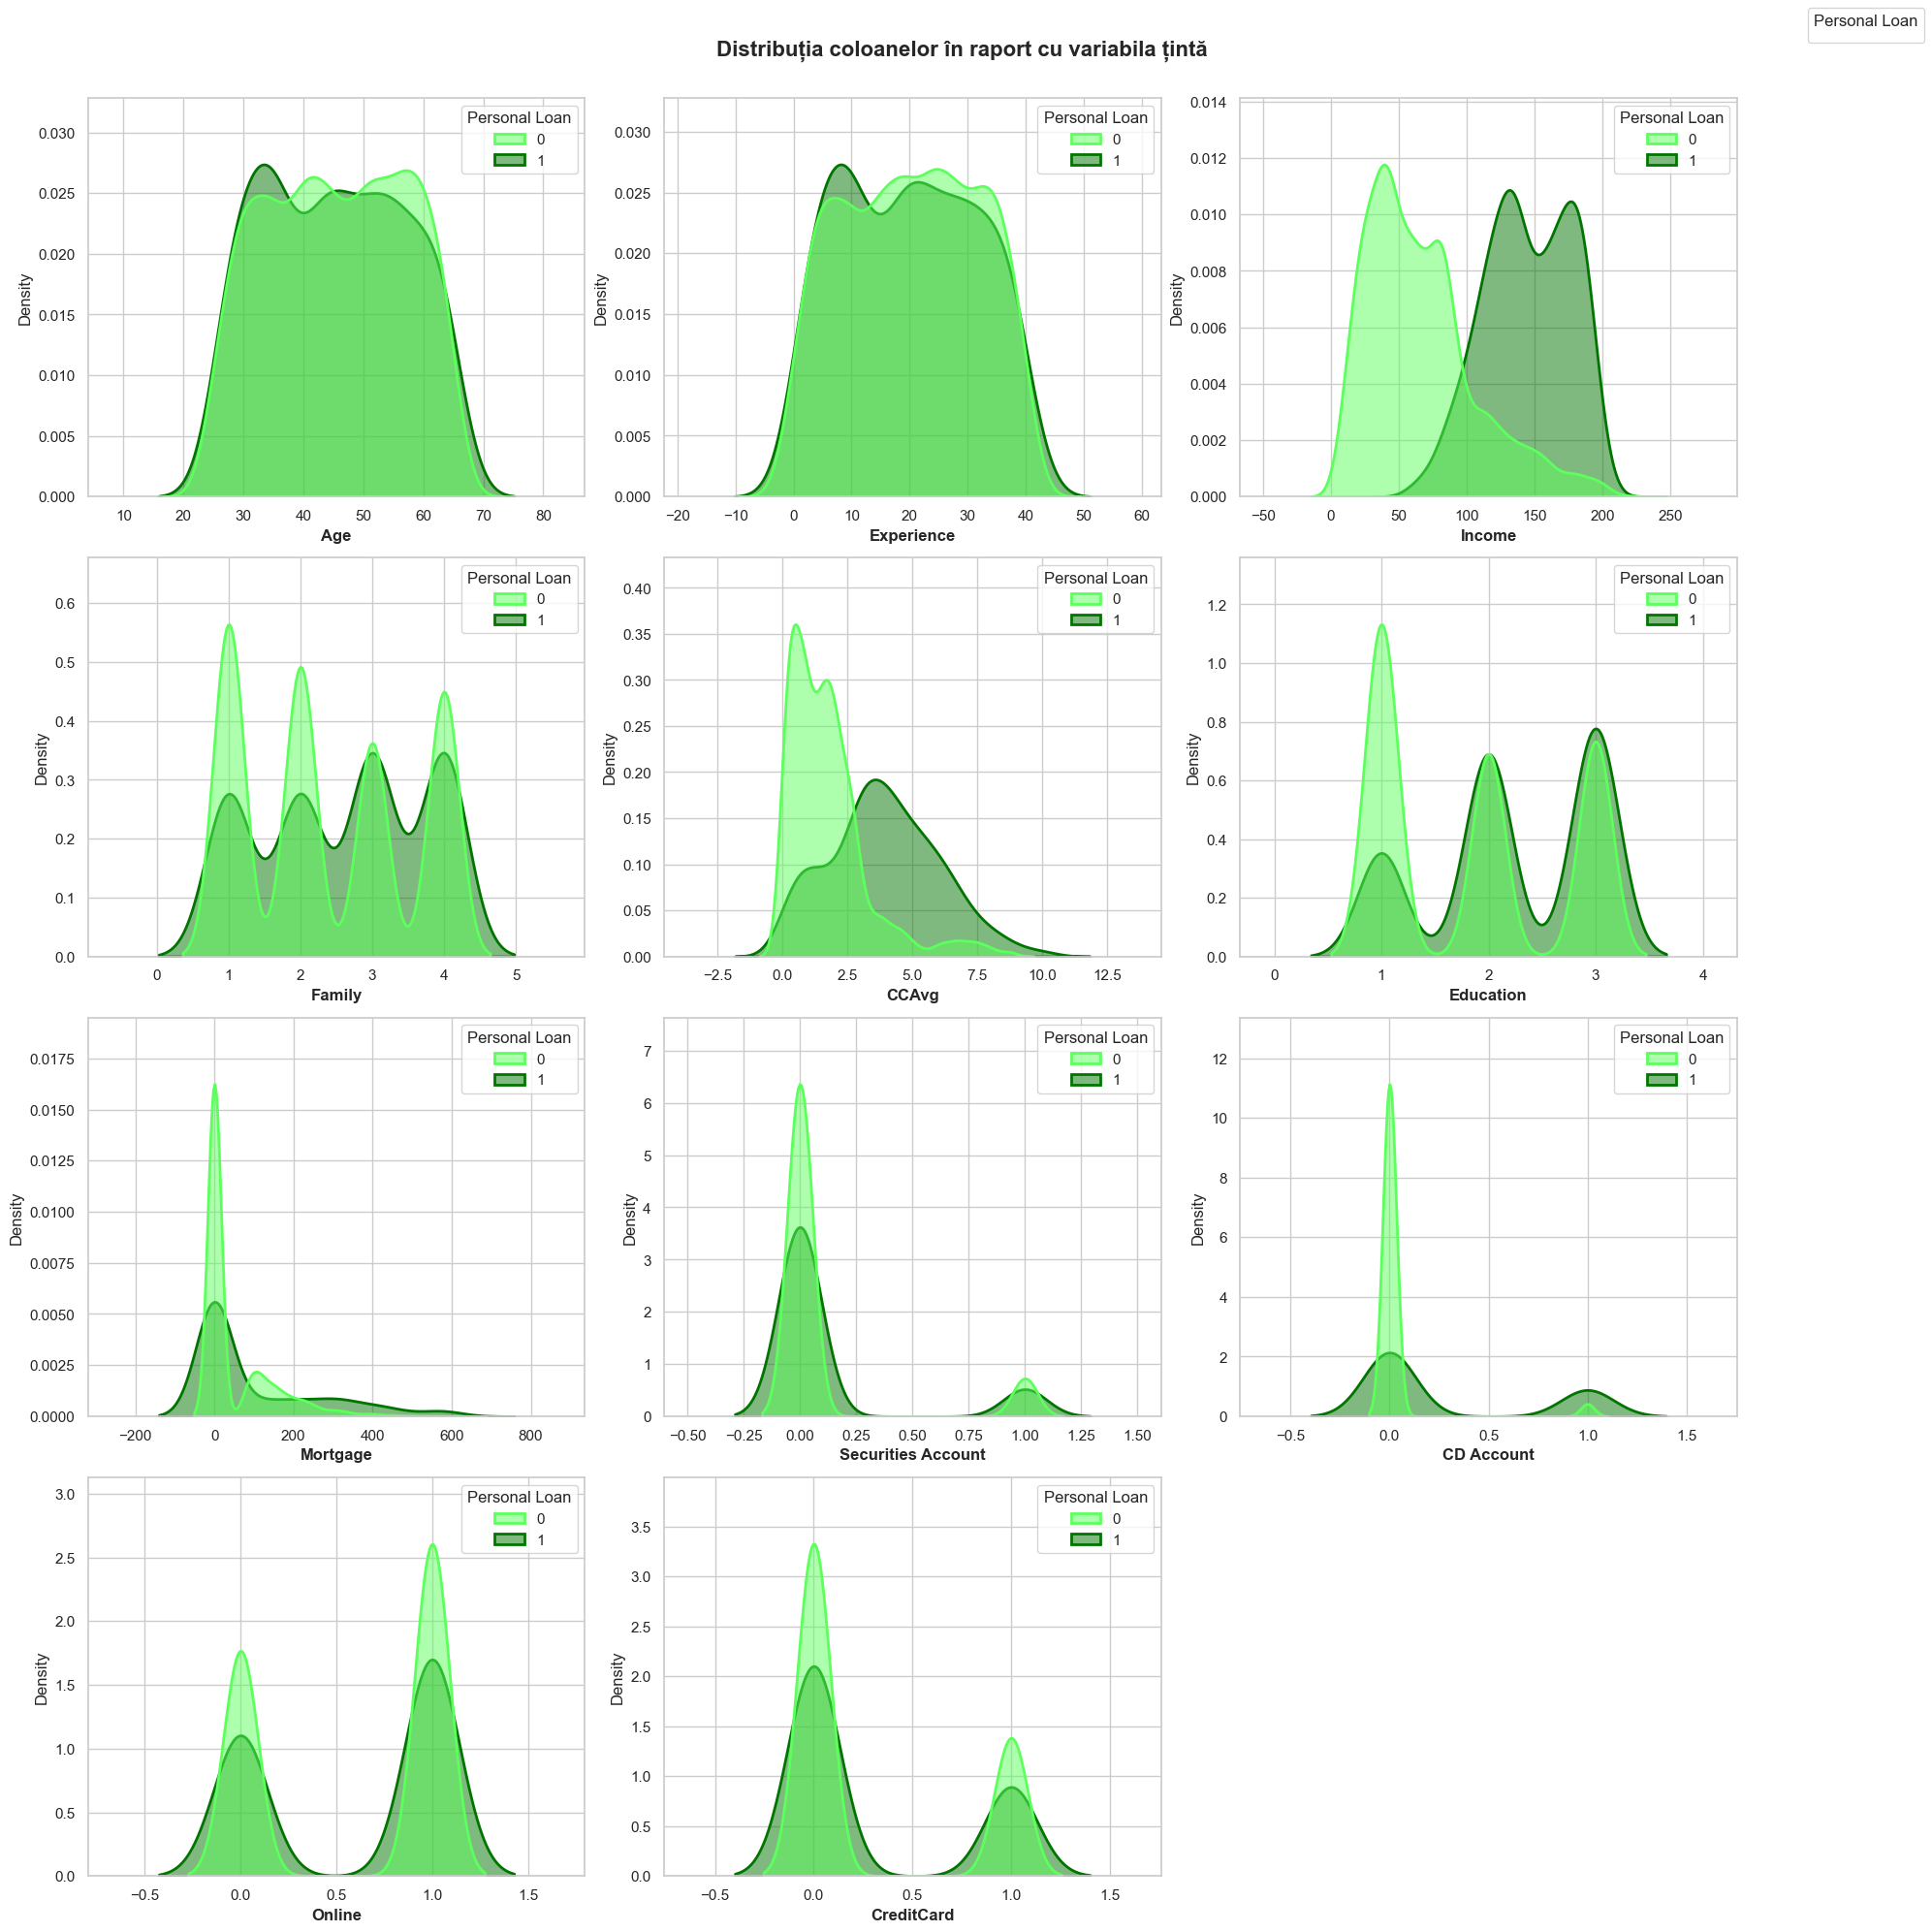

In [83]:
sns.set(style="whitegrid")

columns = df.drop('Personal Loan', axis=1).columns
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.kdeplot(
        x=col, 
        data=df, 
        hue='Personal Loan', 
        fill=True,
        palette=['#5CFF5C', '#007500'], 
        alpha=0.5, 
        lw=2, 
        ax=axes[i],
        common_norm=False
    )
    axes[i].set_xlabel(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Density', fontsize=12)
    
# Setăm legenda doar o singură dată, folosind handles și labels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Personal Loan', loc='upper right', fontsize=12)

# Eliminăm axele goale dacă există
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribuția coloanelor în raport cu variabila țintă', fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.95, right=0.9)
plt.show()

Există relații vizuale clare între variabilele independente și variabila țintă?

Din vizualizarea distribuțiilor variabilelor în raport cu clasa țintă (Personal Loan), se pot extrage următoarele concluzii privind puterea predictivă a datelor:

•	Predictori cu impact ridicat (Separare clară):

	Income (Venit): Se observă o diferență majoră; clienții care acceptă împrumutul (portocaliu) au venituri semnificativ mai mari, majoritatea fiind peste pragul de 100k.
    
	CCAvg (Consum Card): Există o corelație vizuală pozitivă între cheltuielile lunare pe card și probabilitatea de a contracta un credit.
    
	CD Account: Deși este o variabilă rară, prezența unui cont de depozit la termen pare să fie un indicator extrem de puternic al acceptării ofertei.
    
•	Predictori moderați:

	Education: Nivelurile superioare de educație (Graduate și Professional) prezintă o densitate mai mare de acceptare comparativ cu nivelul de licență (Undergrad).
    
	Family: Familiile cu mai mulți membri (3-4) par să aibă o ușoară predispoziție spre împrumuturi, probabil pentru acoperirea unor nevoi financiare crescute.
    
•	Variabile cu impact redus (Zgomot):

	Age & Experience: Distribuțiile sunt aproape perfect suprapuse, ceea ce indică faptul că vârsta sau experiența profesională nu sunt factori discriminanți în acest context.
    
	Mortgage: Deoarece majoritatea clienților nu au ipotecă (valoare 0), variabila nu oferă o separare vizuală utilă în histogramele brute.
    
Concluzie EDA: Modelul de clasificare se va baza în principal pe profilul financiar (Venit, Consum) și pe relația existentă cu banca (CD Account) pentru a genera predicții precise.


Care este dimensiunea setului de date la aceasta secțiune?

Dimensiunea acestui set de date este:(5000, 12),adica 5000 linii si 12 coloane.

2. Analiza datelor și curățarea

In [84]:
df.isnull().sum()

Age                   0
Experience            0
Income                0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [85]:
df.duplicated().sum()


np.int64(13)

In [86]:
# Dicționar pentru a stoca numărul de outlieri per coloană
outliers_dict = {}

for col in df.drop('Personal Loan', axis=1).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_dict[col] = outliers.shape[0]

# Afișăm numărul de outlieri pentru fiecare coloană
outliers_series = pd.Series(outliers_dict).sort_values(ascending=False)
print("Numărul de outlieri per coloană (sortat descrescător):")
print(outliers_series)


Numărul de outlieri per coloană (sortat descrescător):
Securities Account    522
CCAvg                 324
CD Account            302
Mortgage              291
Income                 96
Experience              0
Age                     0
Education               0
Family                  0
Online                  0
CreditCard              0
dtype: int64


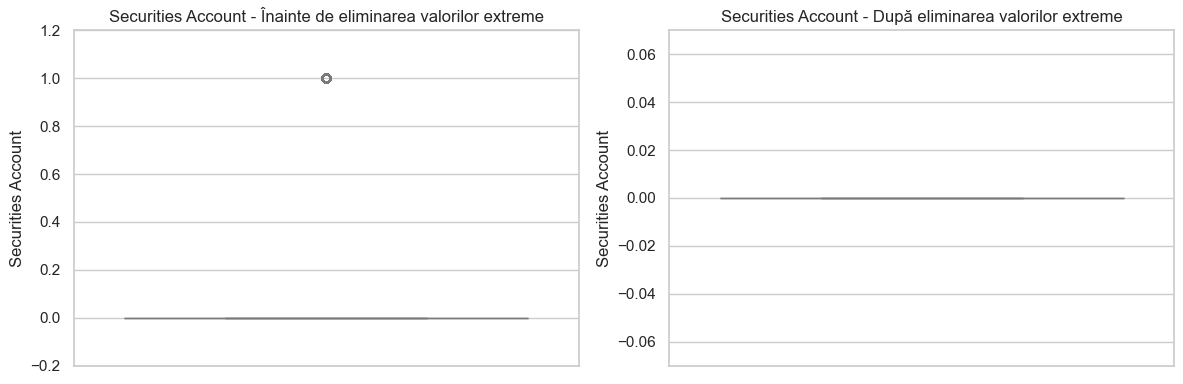

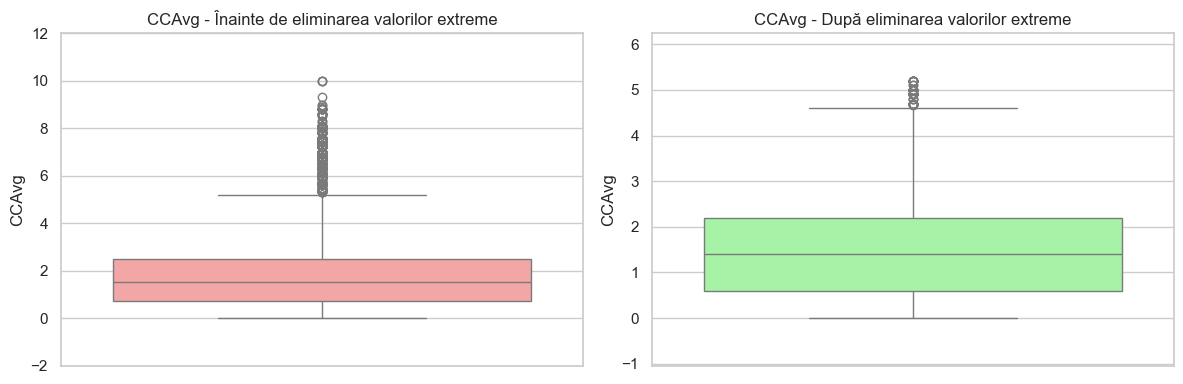

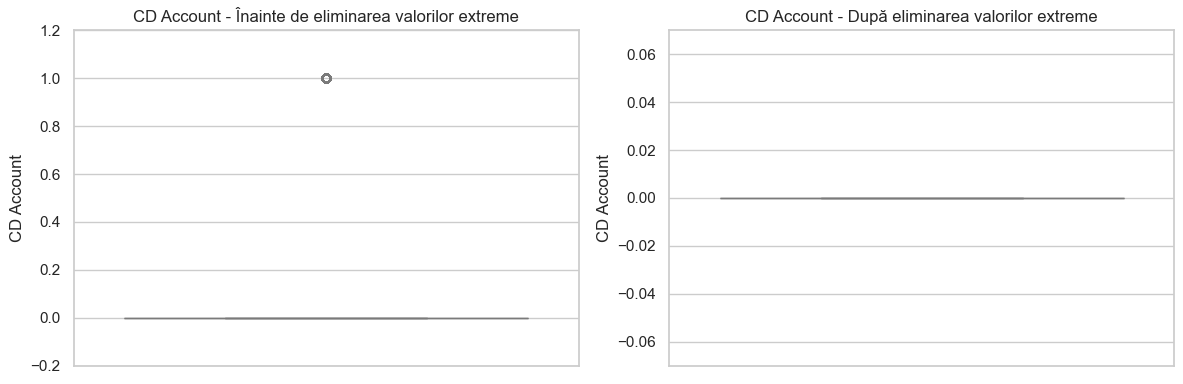

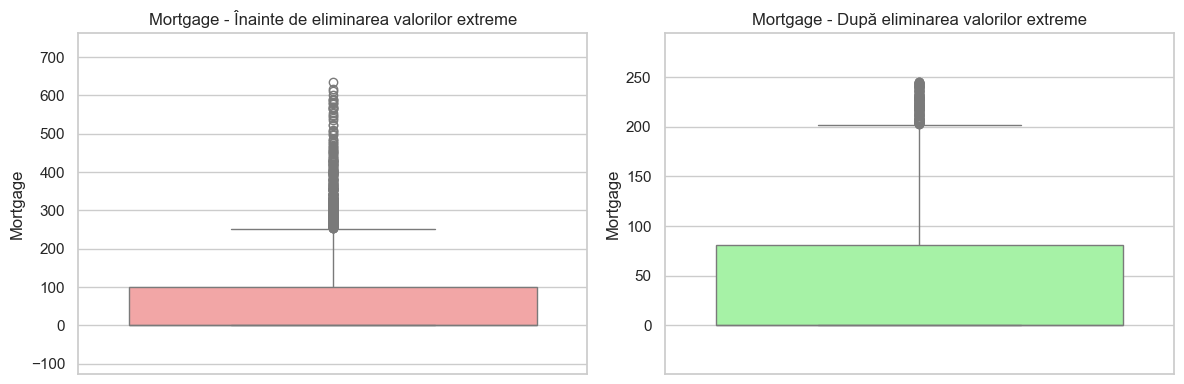

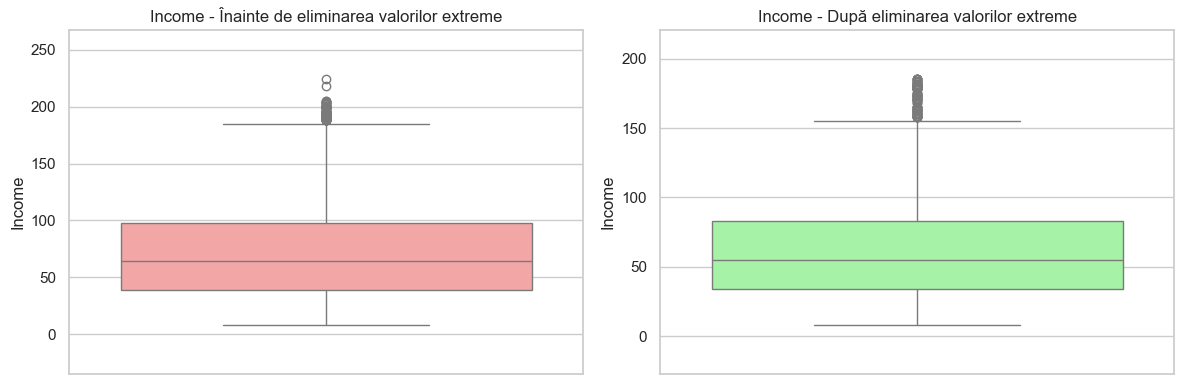

In [87]:
sns.set(style="whitegrid")

# Selectăm primele 5 coloane cu cei mai mulți outlieri
top5_cols = outliers_series.index[:5]

# Copiem dataset-ul pentru comparație
df_before = df.copy()
df_after = df.copy()

# Eliminăm outlierii pentru toate coloanele numerice
for col in df_after.drop('Personal Loan', axis=1).columns:
    Q1 = df_after[col].quantile(0.25)
    Q3 = df_after[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_after = df_after[(df_after[col] >= lower_bound) & (df_after[col] <= upper_bound)]

# Vizualizare boxplot înainte și după pentru primii 5 outlieri
for col in top5_cols:
    plt.figure(figsize=(12,4))

    # Boxplot înainte
    plt.subplot(1,2,1)
    sns.boxplot(y=df_before[col], color='#FF9999')
    plt.title(f'{col} - Înainte de eliminarea valorilor extreme')

    # Boxplot după eliminare
    plt.subplot(1,2,2)
    sns.boxplot(y=df_after[col], color='#99FF99')
    plt.title(f'{col} - După eliminarea valorilor extreme')

    plt.tight_layout()
    plt.show()


In [88]:
df = df.drop_duplicates()

In [89]:
df.duplicated().sum()

np.int64(0)

Nu avem variabile categoriale,iar ținta noastră este deja în formatul pentru modelare.

In [90]:
df.shape


(4987, 12)

Ce variabile aveau valori lipsă sau extreme și cum au fost tratate?

Nu am avut valori lipsă,iar valori extreme am avut pe 5 coloane(Securities Account-522,CCAvg-324,CD Account-302,Mortgage-291
Income-96),dar ulterior le-am șters și am analizat asta și pe graficele de tip boxplot.

Câte variabile numerice și câte categoriale există?

Nu aveam variabile categoriale,iar variabilele numerice sunt în număr de 12.

Care este dimensiunea setului de date la aceasta secțiune?

Acum,dimensiunea setului de date este (4987, 12),adica aveam 4987 linii si 12 coloane.

3.Preprocesarea și pregătirea pentru modelare

In [91]:
corr = df.corr()
corr

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Age,1.000000,0.994221,-0.056897,-0.045533,-0.052522,0.042356,-0.013014,-0.008003,-0.000715,0.007849,0.013989,0.006381
Experience,0.994221,1.000000,-0.048277,-0.051718,-0.050597,0.014166,-0.011083,-0.007708,-0.001529,0.010151,0.014245,0.007628
Income,-0.056897,-0.048277,1.000000,-0.157922,0.646065,-0.186847,0.206420,0.502513,-0.002992,0.169589,0.014646,-0.003479
Family,-0.045533,-0.051718,-0.157922,1.000000,-0.109801,0.066145,-0.020595,0.061398,0.019957,0.014081,0.009907,0.012018
CCAvg,-0.052522,-0.050597,0.646065,-0.109801,1.000000,-0.135285,0.109162,0.366671,0.014572,0.136241,-0.002718,-0.007407
Education,0.042356,0.014166,-0.186847,0.066145,-0.135285,1.000000,-0.032256,0.137618,-0.010132,0.014475,-0.015633,-0.010307
Mortgage,-0.013014,-0.011083,0.206420,-0.020595,0.109162,-0.032256,1.000000,0.141700,-0.005909,0.088987,-0.005266,-0.007930
Personal Loan,-0.008003,-0.007708,0.502513,0.061398,0.366671,0.137618,0.141700,1.000000,0.021670,0.316210,0.006718,0.002399
Securities Account,-0.000715,-0.001529,-0.002992,0.019957,0.014572,-0.010132,-0.005909,0.021670,1.000000,0.316883,0.013096,-0.015466
CD Account,0.007849,0.010151,0.169589,0.014081,0.136241,0.014475,0.088987,0.316210,0.316883,1.000000,0.176414,0.278559


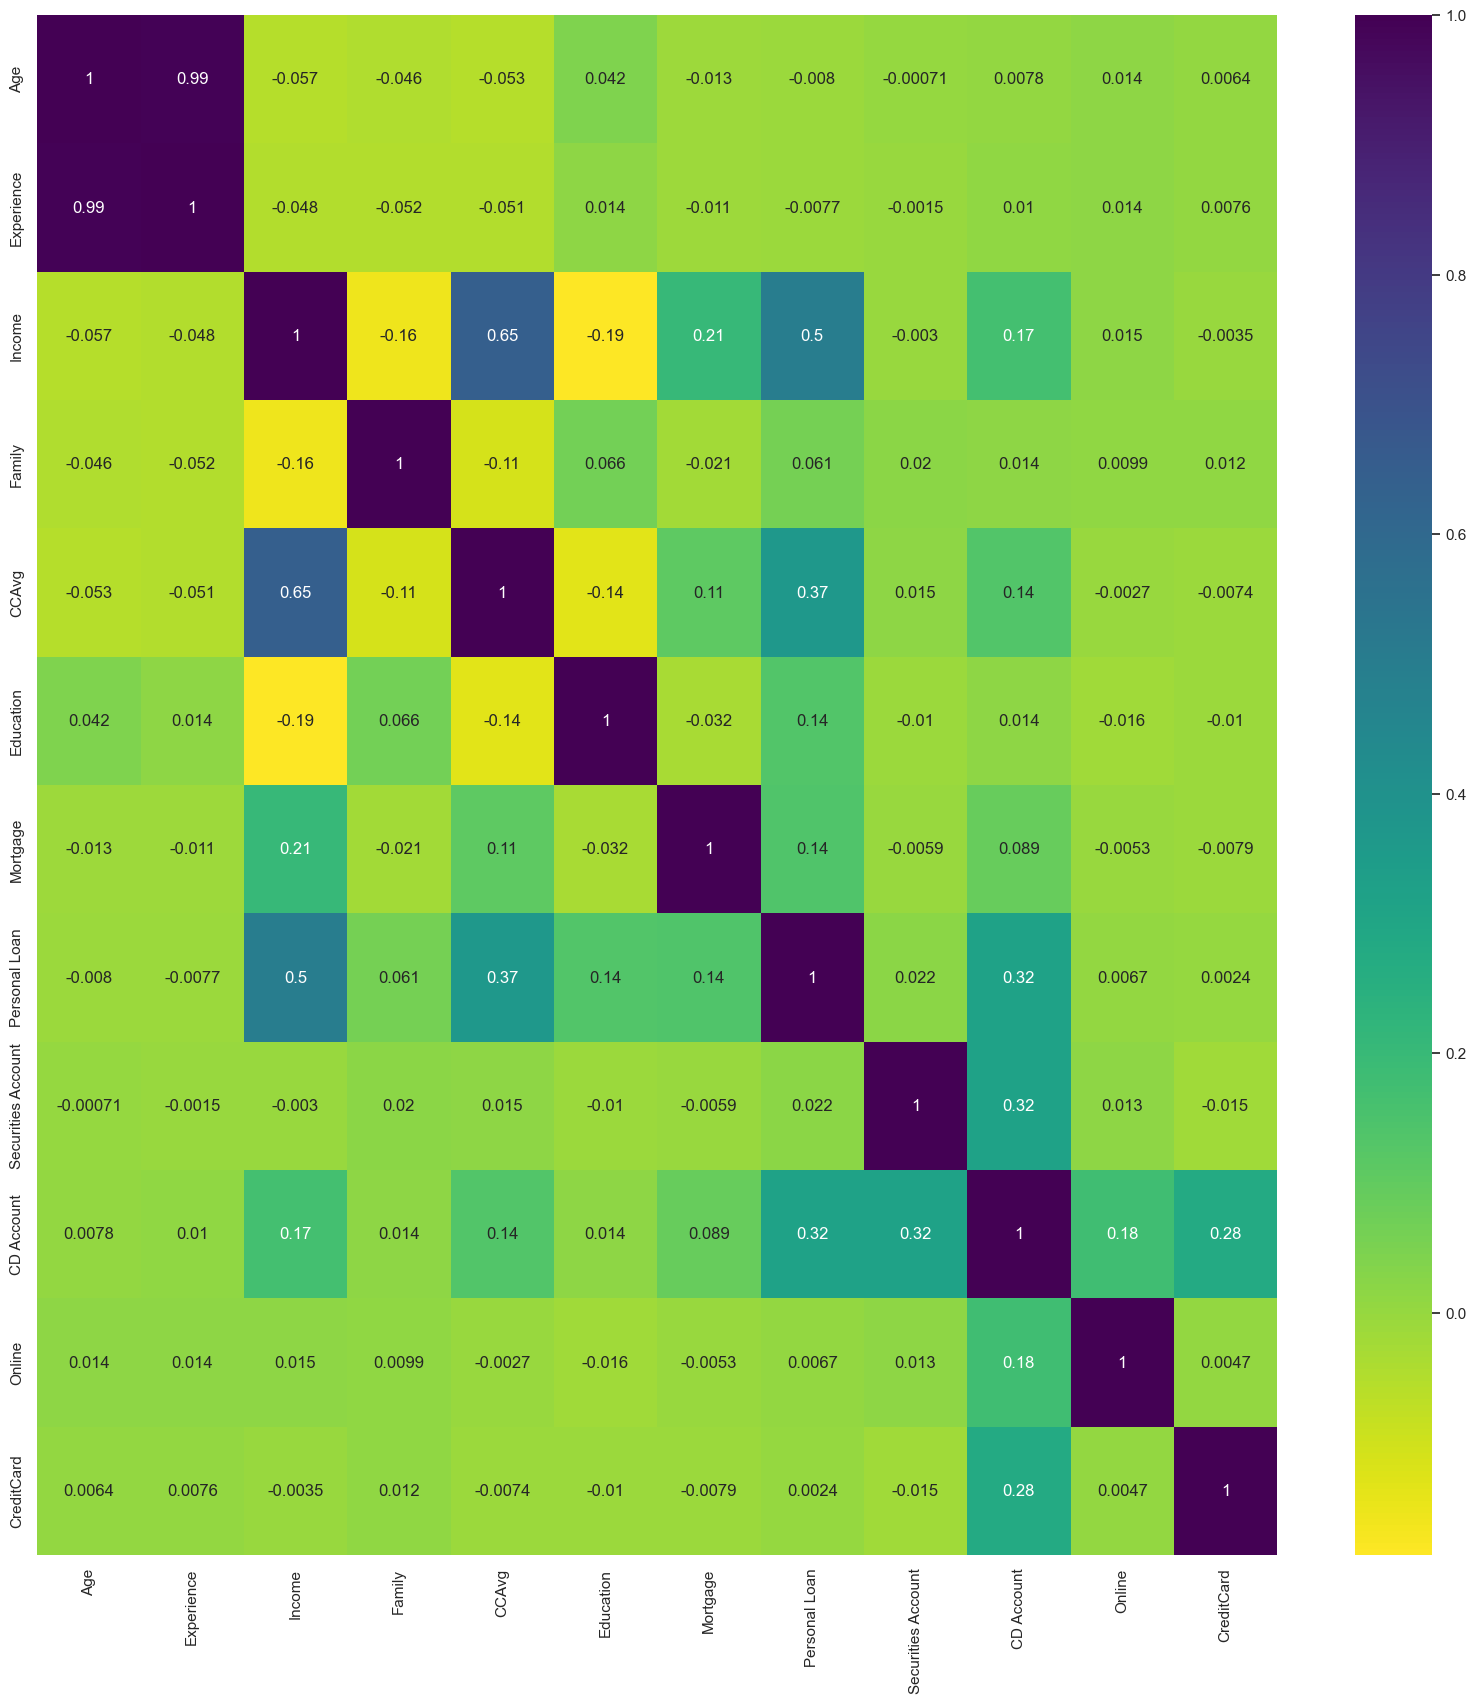

In [92]:
# Calculăm matricea de corelație între toate coloanele numerice
corr = df.corr()

# Setăm dimensiunea figurii
plt.figure(figsize=(20,20))

# Creăm heatmap-ul cu corelațiile
sns.heatmap(corr, cmap='viridis_r', annot=True)

# Afișăm figura
plt.show()

In [93]:
# Matricea de corelație
corr_matrix = df.corr().abs()

# Selectăm doar partea superioară a matricei
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Găsim coloanele care au corelație > 0.8
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

# Eliminăm aceste coloane
df_reduced = df.drop(columns=to_drop)

print("Coloane eliminate din cauza multicoliniarității (corelație > 0.8):")
print(to_drop)
print("Formă nouă DataFrame:", df_reduced.shape)

Coloane eliminate din cauza multicoliniarității (corelație > 0.8):
['Experience']
Formă nouă DataFrame: (4987, 11)


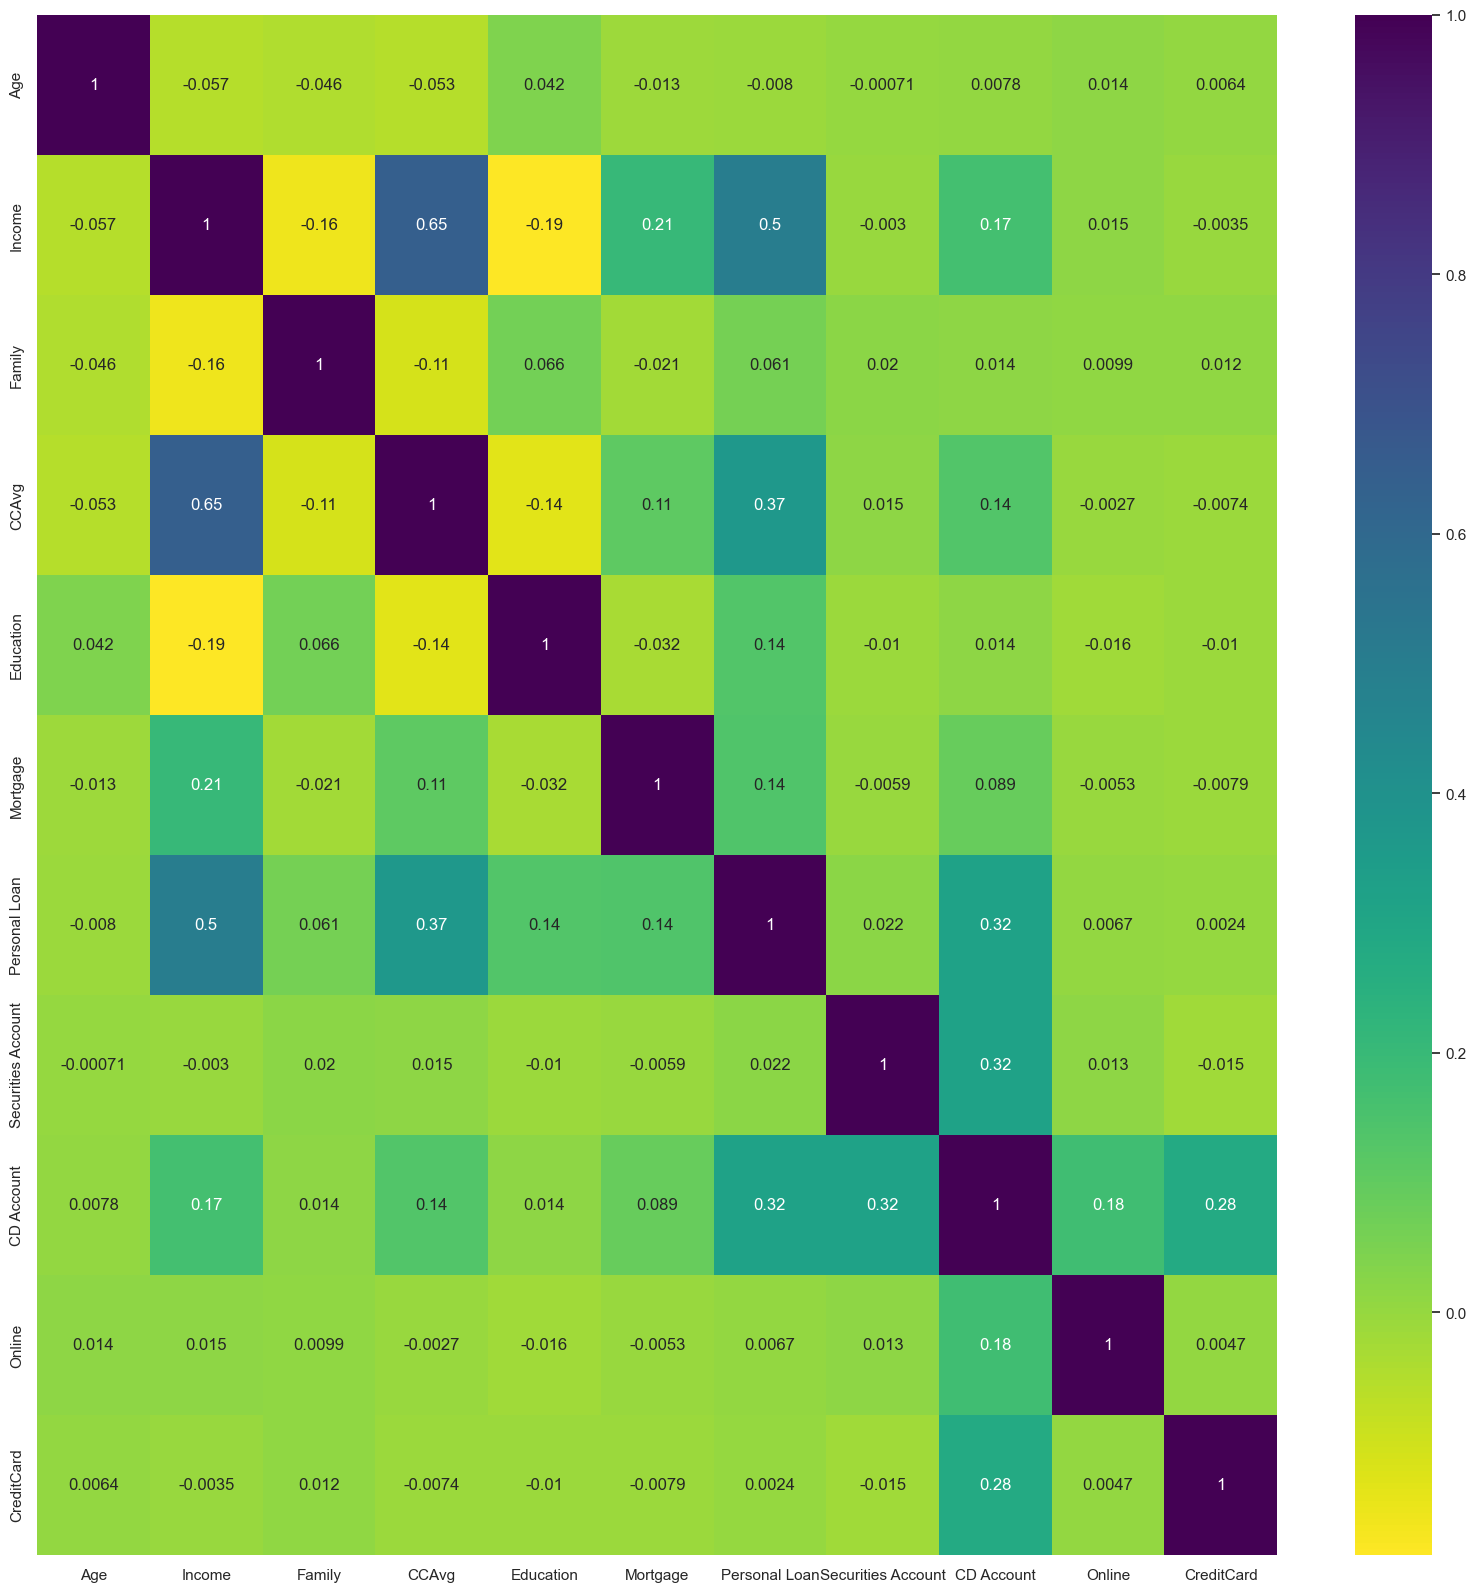

In [94]:
df=df_reduced
# Calculăm matricea de corelație între toate coloanele numerice
corr = df.corr()

# Setăm dimensiunea figurii
plt.figure(figsize=(20,20))

# Creăm heatmap-ul cu corelațiile
# cmap='viridis_r' folosește o schemă de culori inversată
# annot=True afișează valorile numerice pe fiecare pătrat
sns.heatmap(corr, cmap='viridis_r', annot=True)

# Afișăm figura
plt.show()

Împărțirea setului de date

In [95]:
from sklearn.model_selection import train_test_split

# Separăm variabilele independente (X) de variabila țintă (y)
X = df.drop('Personal Loan', axis=1)  # toate coloanele, mai puțin 'diagnosis'
y = df['Personal Loan']               # variabila țintă

# Împărțim dataset-ul în set de antrenament și set de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Verificăm dimensiunile dataset-urilor
print("Dimensiune X_train:", X_train.shape)
print("Dimensiune X_test:", X_test.shape)
print("Dimensiune y_train:", y_train.shape)
print("Dimensiune y_test:", y_test.shape)


Dimensiune X_train: (3490, 10)
Dimensiune X_test: (1497, 10)
Dimensiune y_train: (3490,)
Dimensiune y_test: (1497,)


Scalarea datelor 

In [96]:
from sklearn.preprocessing import StandardScaler

# Inițializăm scaler-ul
scaler = StandardScaler()

# Aplicăm scalarea pe setul de antrenament și test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertim în DataFrame păstrând numele coloanelor
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Verificăm primele rânduri
print("X_train_scaled_df:")
display(X_train_scaled_df.head())

print("X_test_scaled_df:")
display(X_test_scaled_df.head())


X_train_scaled_df:


,Age,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
1409,-0.367823,-0.249572,-0.345019,0.719263,-1.049069,-0.555654,-0.33914,-0.256855,-1.221097,-0.647515
2503,-0.627909,-1.181037,1.405150,-0.892300,0.139649,0.208810,-0.33914,-0.256855,0.818936,1.544365
802,-0.801300,-0.509516,0.530066,0.028593,-1.049069,1.515174,-0.33914,-0.256855,0.818936,-0.647515
1290,1.452784,0.551921,1.405150,-0.144074,0.139649,-0.555654,-0.33914,-0.256855,0.818936,-0.647515
2530,0.932611,-0.942755,1.405150,-0.259186,1.328367,-0.555654,-0.33914,-0.256855,0.818936,-0.647515


X_test_scaled_df:


,Age,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
3760,0.932611,-0.097938,0.530066,-0.316742,1.328367,2.086103,-0.33914,-0.256855,0.818936,1.544365
1539,-1.408169,-1.159375,0.530066,-0.604521,1.328367,0.595881,-0.33914,-0.256855,-1.221097,-0.647515
1665,-0.714605,0.551921,0.530066,-0.431853,1.328367,2.744123,-0.33914,-0.256855,0.818936,1.544365
1077,-1.408169,2.176569,0.530066,0.776819,1.328367,2.628002,-0.33914,-0.256855,0.818936,-0.647515
4209,-0.887996,-1.159375,-0.345019,-0.316742,1.328367,0.653942,-0.33914,-0.256855,0.818936,-0.647515


Cum se gestionează multicoliniaritatea?

Multicoliniaritatea a fost tratată prin analizarea matricii de corelație și eliminarea variabilelor care prezentau corelații puternice între ele (peste pragul de 0.8). În acest caz, variabila Experience a fost eliminată deoarece era aproape perfect corelată cu Age, ceea ce putea afecta stabilitatea și interpretarea modelelor. Eliminarea acestei coloane a permis reducerea redundanței și a riscului de supraajustare, păstrând doar variabilele relevante și independente în setul de date.

Care sunt relațiile cu variabila țintă?

Analiza corelațiilor arată că variabila țintă Personal Loan are relații pozitive moderate cu Income, CCAvg și CD Account, ceea ce sugerează că persoanele cu venituri mai mari, cheltuieli mai ridicate pe card și conturi de tip CD sunt mai predispuse să accepte un credit personal. De asemenea, există o corelație vizibilă cu Education, ceea ce indică o tendință pe segmentul persoanelor cu studii superioare. Restul variabilelor, precum Age, Family sau Mortgage, prezintă valori foarte mici ale corelației, ceea ce sugerează un impact redus asupra probabilității de a contracta un împrumut.

Care sunt dimensiunile seturilor de antrenare și de testare?

După eliminarea variabilei Experience și obținerea unui DataFrame final cu 11 coloane, datele au fost împărțite în seturi de antrenare și testare conform proporției standard. Setul de antrenare (X_train) conține 3.490 de observații și 10 variabile independente, în timp ce setul de testare (X_test) conține 1.497 de observații cu aceleași 10 variabile. Variabilele țintă asociate au aceleași dimensiuni: y_train include 3.490 de etichete, iar y_test include 1.497 de etichete, pregătind astfel datele pentru antrenarea și evaluarea modelelor predictive.


4.Modelul arborelui de decizie

In [97]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


# Creăm modelul implicit (fără setarea max_depth sau min_samples_split)
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_scaled_df, y_train)

# Predicții pe train și test
y_train_pred = dt_default.predict(X_train_scaled_df)
y_test_pred = dt_default.predict(X_test_scaled_df)

# Acuratețe
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print("=== Model Implicit ===")
print(f"Acuratețe Train: {acc_train:.3f}")
print(f"Acuratețe Test: {acc_test:.3f}")
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))


=== Model Implicit ===
Acuratețe Train: 1.000
Acuratețe Test: 0.980

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1358
           1       0.90      0.88      0.89       139

    accuracy                           0.98      1497
   macro avg       0.94      0.94      0.94      1497
weighted avg       0.98      0.98      0.98      1497



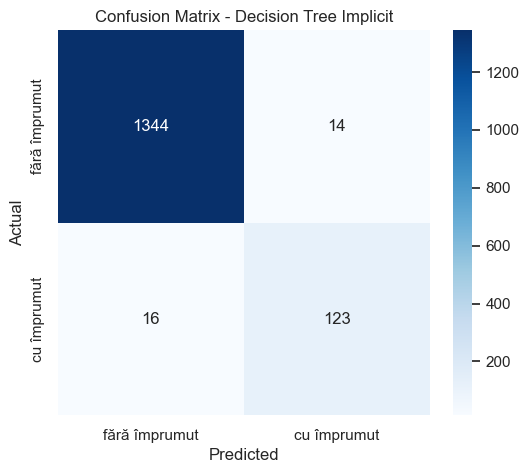

In [98]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculăm matricea de confuzie
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['fără împrumut','cu împrumut'], yticklabels=['fără împrumut','cu împrumut'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree Implicit')
plt.show()


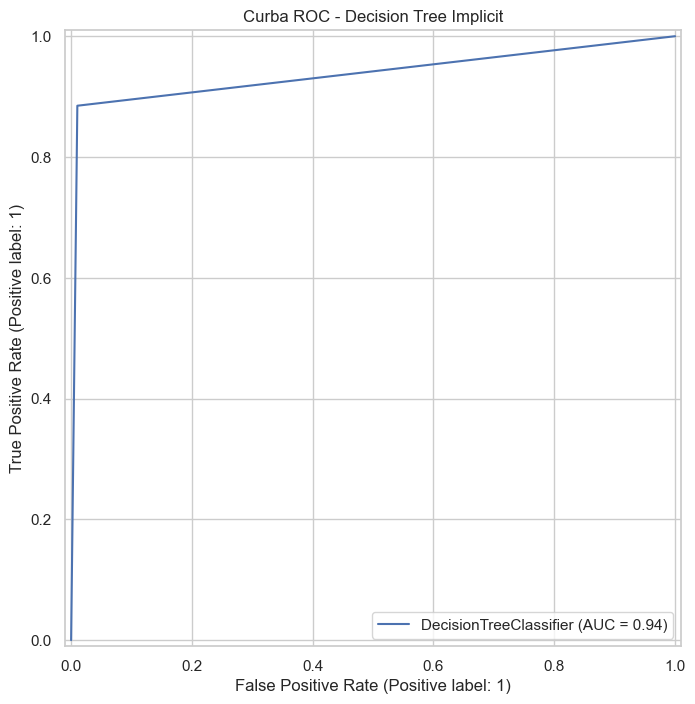

In [99]:
from sklearn.metrics import RocCurveDisplay


# Curba ROC direct din model
RocCurveDisplay.from_estimator(
    dt_default,          # modelul antrenat
    X_test_scaled_df,    # datele de test
    y_test               # etichetele reale
)

plt.title("Curba ROC - Decision Tree Implicit")
plt.show()


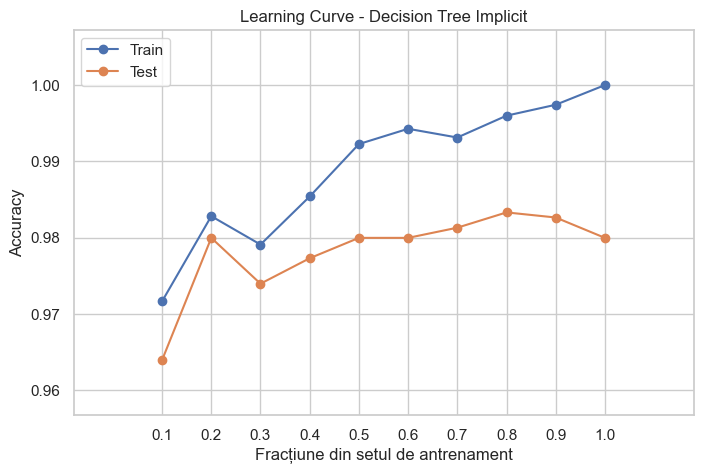

In [100]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Listă de dimensiuni pentru subsetul de antrenament
train_sizes_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

accuracy_train = []
accuracy_test = []

for frac in train_sizes_list:
    n_train = int(len(X_train_scaled_df) * frac)
    
    # Subset din setul de antrenament
    X_train_subset = X_train_scaled_df.iloc[:n_train]
    y_train_subset = y_train.iloc[:n_train]
    
    # Model implicit
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train_subset, y_train_subset)
    
    # Predicții
    y_train_pred = model.predict(X_train_scaled_df)
    y_test_pred = model.predict(X_test_scaled_df)
    
    # Accuracy
    accuracy_train.append(accuracy_score(y_train, y_train_pred))
    accuracy_test.append(accuracy_score(y_test, y_test_pred))

# Plot 
plt.figure(figsize=(8,5))
plt.plot(train_sizes_list, accuracy_train, marker='o')
plt.plot(train_sizes_list, accuracy_test, marker='o')
plt.title('Learning Curve - Decision Tree Implicit')
plt.xlabel('Fracțiune din setul de antrenament')
plt.ylabel('Accuracy')
plt.xticks(train_sizes_list)
plt.grid(True)
plt.legend(['Train', 'Test'])
plt.show()


1. Care este performanța arborelui de decizie?

   
Arborele de decizie are o performanță foarte ridicată, cu o acuratețe de 1.00 pe setul de antrenament, ceea ce indică un model perfect pe datele pe care le-a văzut, dar și un posibil risc de suprainvățare. Pe setul de testare, acuratețea este de 0.98, ceea ce arată că modelul generalizează foarte bine. Indicatorii suplimentari arată o precizie de 0.99 pentru clasa majoritară (0) și 0.90 pentru clasa minoritară (1), în timp ce recall-ul este 0.99 pentru clasa 0 și 0.88 pentru clasa 1. În ansamblu, modelul este performant, dar se observă o ușoară scădere în detectarea cazurilor de tipul 1, ceea ce este normal în situații cu dezechilibru de clasă.

2. Ce reprezintă valorile din matricea de confuzie și curba ROC pentru model?
   
Matricea de confuzie arată modul concret în care modelul clasifică exemplele: 1344 cazuri negative au fost corect clasificate, 14 au fost clasificate greșit ca fiind pozitive, iar pentru clasa pozitivă modelul a prezis corect 123 de cazuri, ratând 16. Acest lucru confirmă un model foarte precis, cu puține erori. Curba ROC ilustrează compromisul dintre rata de adevărate pozitive și rata de false pozitive pentru toate pragurile posibile ale modelului, iar scorul AUC de 0.94 indică o capacitate excelentă de a separa cele două clase. Cu cât curba este mai aproape de colțul stânga-sus, cu atât modelul este mai bun — iar aici modelul este clar performant.

5.Modelul Random Forest

In [101]:
from sklearn.ensemble import RandomForestClassifier

# Model implicit Random Forest
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train_scaled_df, y_train)

# Predicții
y_train_pred = rf_default.predict(X_train_scaled_df)
y_test_pred = rf_default.predict(X_test_scaled_df)

# Acuratețe
print("=== Random Forest Implicit ===")
print(f"Acuratețe Train: {accuracy_score(y_train, y_train_pred):.3f}")

rf_train=accuracy_score(y_train, y_train_pred)

print(f"Acuratețe Test: {accuracy_score(y_test, y_test_pred):.3f}")

rf_accuracy=accuracy_score(y_test, y_test_pred)

# Classification Report
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))



=== Random Forest Implicit ===
Acuratețe Train: 1.000
Acuratețe Test: 0.988

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1358
           1       0.99      0.88      0.93       139

    accuracy                           0.99      1497
   macro avg       0.99      0.94      0.96      1497
weighted avg       0.99      0.99      0.99      1497



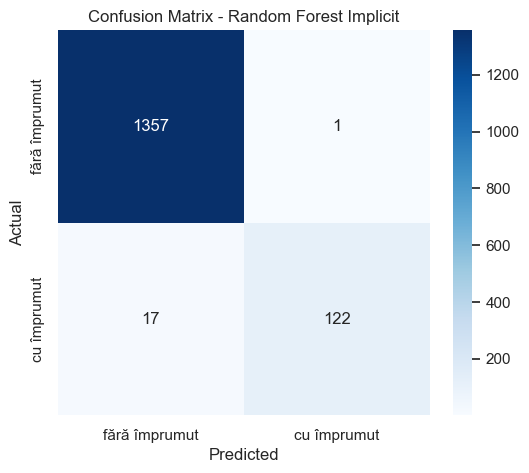

In [102]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['fără împrumut','cu împrumut'], yticklabels=['fără împrumut','cu împrumut'])
plt.title('Confusion Matrix - Random Forest Implicit')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

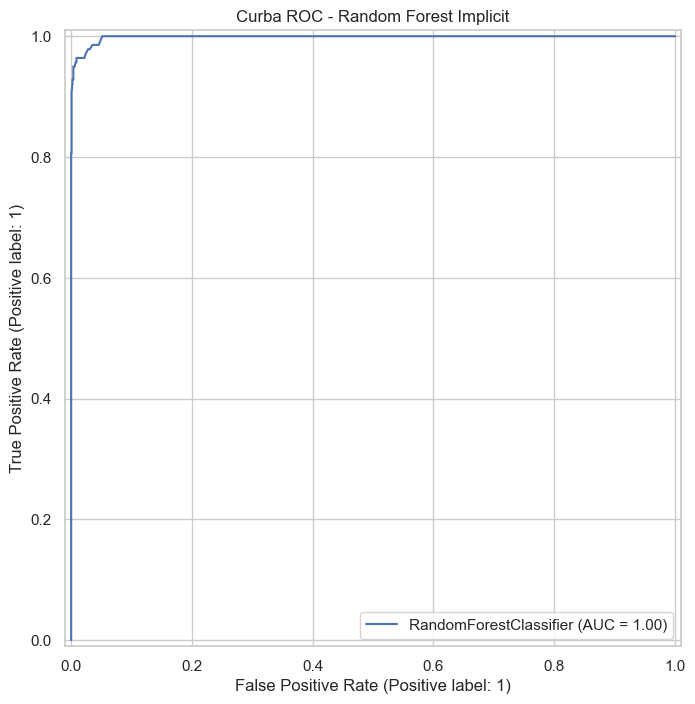

In [103]:
from sklearn.metrics import RocCurveDisplay


# Curba ROC direct din model
RocCurveDisplay.from_estimator(
    rf_default,          # modelul antrenat
    X_test_scaled_df,    # datele de test
    y_test               # etichetele reale
)

plt.title("Curba ROC - Random Forest Implicit")
plt.show()

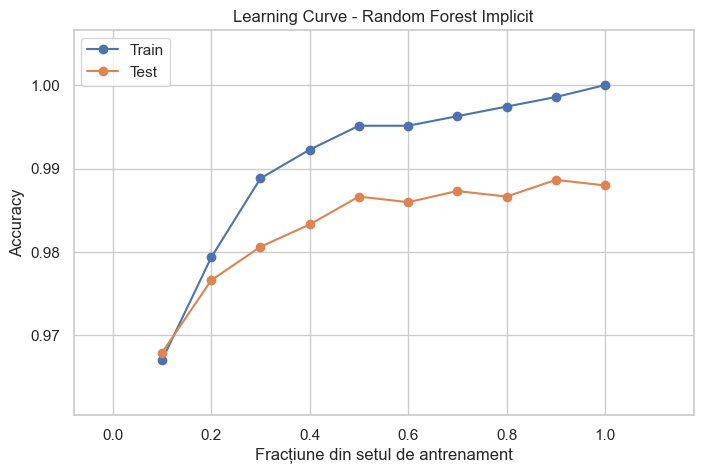

In [104]:
# Learning Curve simplu
train_sizes_list = np.linspace(0.1, 1.0, 10)
accuracy_train = []
accuracy_test = []

for frac in train_sizes_list:
    n_train = int(len(X_train_scaled_df) * frac)
    X_train_subset = X_train_scaled_df.iloc[:n_train]
    y_train_subset = y_train.iloc[:n_train]
    
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_subset, y_train_subset)
    
    y_train_pred_full = model.predict(X_train_scaled_df)
    y_test_pred_full = model.predict(X_test_scaled_df)
    
    accuracy_train.append(accuracy_score(y_train, y_train_pred_full))
    accuracy_test.append(accuracy_score(y_test, y_test_pred_full))

plt.figure(figsize=(8,5))
plt.plot(train_sizes_list, accuracy_train, marker='o')
plt.plot(train_sizes_list, accuracy_test, marker='o')
plt.title('Learning Curve - Random Forest Implicit')
plt.xlabel('Fracțiune din setul de antrenament')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(['Train', 'Test'])
plt.show()



Care este performanța comparativ cu arborele de decizie?

Random Forest depășește arborele de decizie în performanță, având o acuratețe mai mare pe setul de test (0.988 față de aproximativ 0.98) și un scor AUC perfect (1.00 față de 0.94). În timp ce arborele de decizie tinde să suprainvețeze și este mai sensibil la variațiile din date, Random Forest reduce această problemă prin combinarea mai multor arbori și obține o generalizare mai bună. De asemenea, modelul Random Forest clasifică mai precis clasa minoritară, având o precizie mai ridicată și o robusteză superioară față de arborele individual.

Ce reprezintă valorile din matricea de confuzie și curba ROC pentru model?

Matricea de confuzie arată modul concret în care modelul clasifică exemplele: 1357 de cazuri „Fără Împrumut” au fost prezise corect și doar 1 a fost greșit etichetat ca fiind „Cu Împrumut”. Pentru clasa pozitivă, modelul a identificat corect 122 de cazuri și a ratat 17, prezicându-le ca fiind negative. Aceste valori arată că modelul este foarte precis pentru clasa majoritară și, în același timp, are o performanță foarte bună și pe clasa minoritară, cu un număr redus de erori.

Curba ROC ilustrează capacitatea modelului de a diferenția între cele două clase pentru toate pragurile posibile de decizie, punând în relație rata de adevărate pozitive cu rata de false pozitive. În cazul acestui model, curba se apropie aproape perfect de colțul stânga-sus, iar scorul AUC egal cu 1.00 indică o separare ideală între clase. Cu alte cuvinte, modelul Random Forest reușește să distingă extrem de bine între „Cu Împrumut” și „Fără Împrumut”, confirmând performanța sa ridicată.

6.Modelul Boosting (Gradient Boosting)

In [105]:
from sklearn.ensemble import GradientBoostingClassifier

# Model implicit
gb_default = GradientBoostingClassifier(random_state=42)
gb_default.fit(X_train_scaled_df, y_train)

# Predicții și evaluare
y_train_pred = gb_default.predict(X_train_scaled_df)
y_test_pred = gb_default.predict(X_test_scaled_df)

print("=== Gradient Boosting Implicit ===")
print(f"Accuracy Train: {accuracy_score(y_train, y_train_pred):.3f}")
gr_train=accuracy_score(y_train, y_train_pred)
print(f"Accuracy Test: {accuracy_score(y_test, y_test_pred):.3f}")
gr_accuracy=accuracy_score(y_test, y_test_pred)
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))


=== Gradient Boosting Implicit ===
Accuracy Train: 0.994
Accuracy Test: 0.987

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1358
           1       0.97      0.89      0.93       139

    accuracy                           0.99      1497
   macro avg       0.98      0.94      0.96      1497
weighted avg       0.99      0.99      0.99      1497



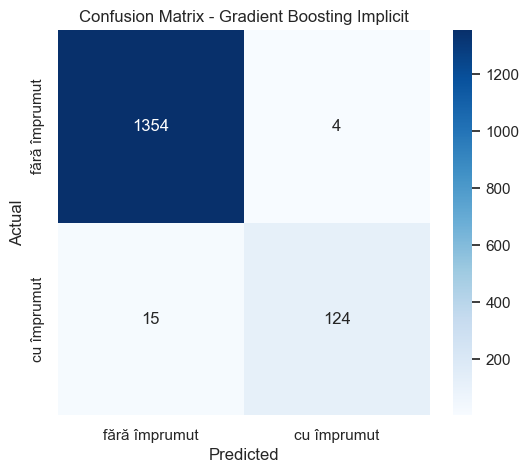

In [106]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['fără împrumut','cu împrumut'], yticklabels=['fără împrumut','cu împrumut'])
plt.title('Confusion Matrix - Gradient Boosting Implicit')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

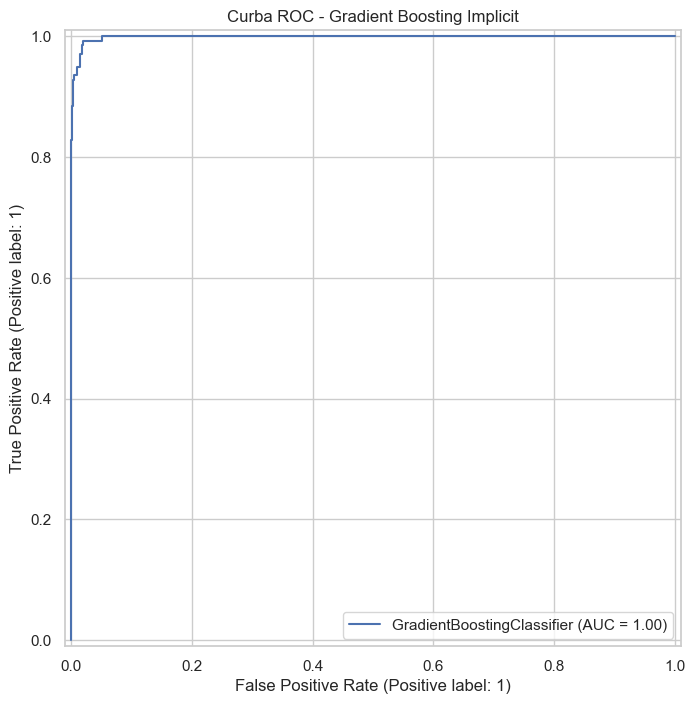

In [107]:
from sklearn.metrics import RocCurveDisplay


# Curba ROC direct din model
RocCurveDisplay.from_estimator(
    gb_default,          # modelul antrenat
    X_test_scaled_df,    # datele de test
    y_test               # etichetele reale
)

plt.title("Curba ROC - Gradient Boosting Implicit")
plt.show()


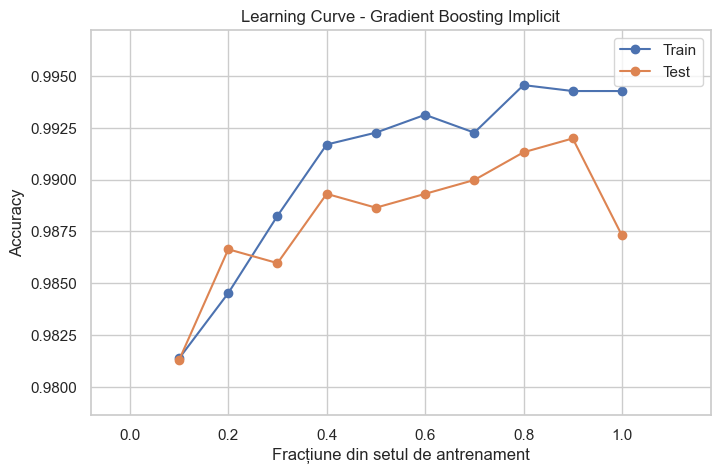

In [108]:
# Learning curve simplu
accuracy_train = []
accuracy_test = []

for frac in train_sizes_list:
    n_train = int(len(X_train_scaled_df) * frac)
    X_train_subset = X_train_scaled_df.iloc[:n_train]
    y_train_subset = y_train.iloc[:n_train]
    
    model = GradientBoostingClassifier(random_state=42)
    model.fit(X_train_subset, y_train_subset)
    
    y_train_pred_full = model.predict(X_train_scaled_df)
    y_test_pred_full = model.predict(X_test_scaled_df)
    
    accuracy_train.append(accuracy_score(y_train, y_train_pred_full))
    accuracy_test.append(accuracy_score(y_test, y_test_pred_full))

plt.figure(figsize=(8,5))
plt.plot(train_sizes_list, accuracy_train, marker='o')
plt.plot(train_sizes_list, accuracy_test, marker='o')
plt.title('Learning Curve - Gradient Boosting Implicit')
plt.xlabel('Fracțiune din setul de antrenament')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(['Train', 'Test'])
plt.show()

Care este performanța comparativ cu modelul Random Forest?

Gradient Boosting prezintă o performanță foarte apropiată de cea a modelului Random Forest, având o acuratețe pe setul de test de 0.987 (față de 0.988 la Random Forest) și un AUC tot de 1.00. Diferența principală este că Gradient Boosting tinde să fie puțin mai sensibil la variațiile din date și are un recall ceva mai scăzut pe clasa pozitivă (0.89 față de aproape perfect în cazul Random Forest). Cu toate acestea, modelul reușește să capteze foarte bine structura datelor și oferă o performanță excelentă, comparabilă și foarte apropiată de Random Forest, confirmând că este un model puternic, dar cu un ușor compromis în detectarea clasei minoritare.

Ce reprezintă valorile din matricea de confuzie și curba ROC pentru model?

Matricea de confuzie arată că modelul Gradient Boosting clasifică aproape perfect clasa „Fără Împrumut”, cu 1354 predicții corecte și doar 4 greșite, în timp ce pentru clasa „Cu Împrumut” acesta identifică corect 124 de cazuri, dar ratează 15, prezicându-le ca fiind negative. Aceste valori evidențiază că modelul este foarte precis pe clasa majoritară și suficient de performant pe clasa minoritară, deși mai puțin exact decât Random Forest la identificarea observațiilor pozitive. Curba ROC se apropie de colțul stânga-sus, iar AUC = 1.00 indică o capacitate excelentă de separare între clase, ceea ce înseamnă că modelul distinge foarte bine între „Cu Împrumut” și „Fără Împrumut” indiferent de pragul de decizie ales.

7.Compararea modelelor și concluzii

In [109]:
# -----------------------------
# Crearea unui DataFrame pentru compararea modelelor
# -----------------------------

import pandas as pd

models = pd.DataFrame({
    'Model': [
        'Decision tree',   
        'Random Forest',           
        'Gradient Boosting'         
    ],
    'Training Accuracy': [
        acc_train, rf_train, gr_train  # Acuratețea pe setul de training
    ],
    
    'Model Accuracy Score': [
        acc_test, rf_accuracy, gr_accuracy  # Acuratețea pe setul de test
    ]
})

# Afișarea DataFrame-ul
models

,Model,Training Accuracy,Model Accuracy Score
0,Decision tree,1.000000,0.979960
1,Random Forest,1.000000,0.987976
2,Gradient Boosting,0.994269,0.987308


In [110]:
# Tabel comparativ al acurateței modelelor
models.sort_values(
    by='Model Accuracy Score', ascending=False
)

,Model,Training Accuracy,Model Accuracy Score
1,Random Forest,1.000000,0.987976
2,Gradient Boosting,0.994269,0.987308
0,Decision tree,1.000000,0.979960


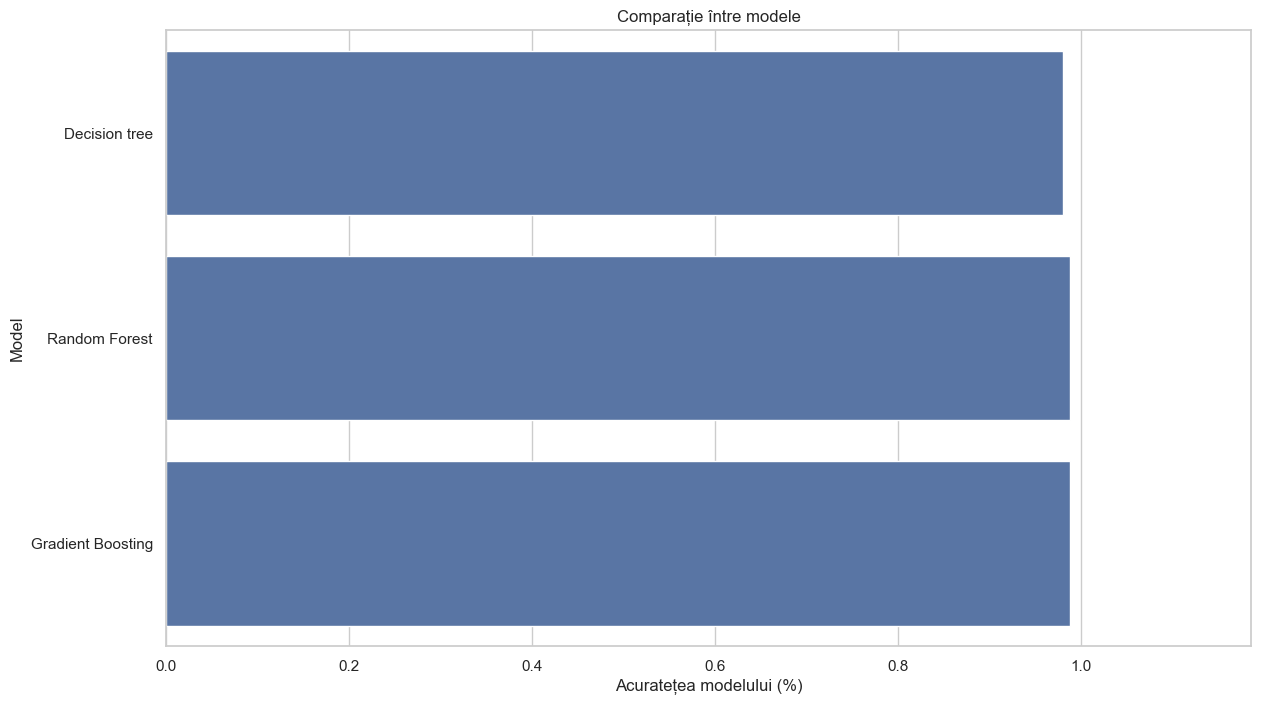

In [111]:
# -----------------------------
# Setări generale pentru grafice
# -----------------------------
plt.rcParams['figure.figsize'] = (14, 8)   # dimensiunea figurii
plt.rcParams['font.size'] = 15             # dimensiunea fontului
plt.rcParams['axes.xmargin'] = 0.2         # marginea axei X
plt.rcParams['axes.ymargin'] = 0.2         # marginea axei Y

# -----------------------------
# Grafic comparativ al acurateței modelelor
# -----------------------------
sns.barplot(
    y='Model', 
    x='Model Accuracy Score', 
    data=models
)

# Titlul și etichetele axelor în română
plt.title('Comparație între modele')
plt.xlabel('Acuratețea modelului (%)')
plt.ylabel('Model')

# Afișarea graficului
plt.show()


Modelul care a oferit cea mai bună performanță este Random Forest, conform tabelului de scoruri de acuratețe obținute pe setul de date de testare (Model Accuracy Score). Acesta a obținut un scor de 0.987976, fiind cel mai înalt dintre cele trei modele analizate. Imediat sub el s-a clasat Gradient Boosting cu un scor de 0.987308, iar pe ultimul loc, dar cu performanțe foarte bune, a fost Decision Tree, cu 0.979960. Prin urmare, Random Forest este opțiunea optimă pentru această sarcină de clasificare.